# Despike Quality Control
One of the more useful components of quality control is the ability to remove spikes from the data. In optical data, these spikes are often real, representing sinking aggregate particles or zooplankton (Briggs et al. 2011). For other sensor types, these spikes can be detrimental to data quality not only within the single sensor, but any derived variables as well.

These spikes are particularly insidious, as they can damage filters that operate on standard deviations or rolling averages, or are undetectable by range tests. For example, a pressure spike that is only 30 m may not be caught in a range test, yet the spike in that pressure value may be used in the derivation of other sensors on the package, meaning multiple values are now wrong for this data index.

This notebook seeks to explore some of the common despiking methods in glider quality control toolboxes and intercompare them for useage in the `pelagos-py` toolbox.

Setting up this pipeline, we need to know what the Spike Test will require.

* Data sometimes come as just the descent or ascent, leading to jumps from one end of the profile to the other. The Spike Test can handle this by looping through `PROFILE_NUMBERS`, if they are defined.
    * This requires the "Find Profiles" step, which in turn requires `DEPTH` to be defined.
* We're working on NRT data, so it's a good idea to interpolate the data as done in the pipeline demo.
    * This requires QC be done on our interpolated data columns, so we'll need to run a couple of QC tests from "Apply QC".
* Finally, to run any QC, we need our data. We can use "Load OG1" to do this.

All of this comes together in a configuration that looks like this:
* Load OG1
* Apply QC
* Interpolate Data
* Derive CTD
* Find Profiles
* Apply QC (**"spike qc"** is fully integrated here.)

Start by initializing as done in other notebooks. Import the important libraries and load the data.

In [1]:
from pathlib import Path
import xarray as xr
import os
import matplotlib.pyplot as plt

cwd = os.getcwd()
os.chdir(f"{cwd}/../../src")

input_dir = Path("../examples/data/OG1")
input_file = input_dir / "Nelson_646_R.nc"
if not input_dir.exists():
    input_dir.mkdir(parents=True)
if not input_file.exists():
    import requests
    response = requests.get("https://linkedsystems.uk/erddap/files/Public_OG1_Data_001/Nelson_20240528/Nelson_646_R.nc")
    if response.status_code == 200:
        with open(input_file, "wb") as f:
            f.write(response.content)
        print(f"Example file downloaded and written to {input_dir.resolve()}")
    else:
        print("File download failed")
dataset = xr.load_dataset("../examples/data/OG1/Nelson_646_R.nc")
dataset

<xarray.Dataset> Size: 443MB
Dimensions:                               (N_MEASUREMENTS: 2014856, N_PARAM: 24)
Dimensions without coordinates: N_MEASUREMENTS, N_PARAM
Data variables: (12/68)
    TIME                                  (N_MEASUREMENTS) datetime64[ns] 16MB ...
    TIME_GPS                              (N_MEASUREMENTS) datetime64[ns] 16MB ...
    PHASE                                 (N_MEASUREMENTS) float32 8MB nan .....
    PHASE_QC                              (N_MEASUREMENTS) float32 8MB nan .....
    CNDC                                  (N_MEASUREMENTS) float32 8MB 0.0 .....
    PRES                                  (N_MEASUREMENTS) float32 8MB 0.0 .....
    ...                                    ...
    PLATFORM_TYPE                         <U6 24B 'slocum'
    PLATFORM_MODEL                        <U2 8B 'G2'
    WMO_IDENTIFIER                        <U3 12B '830'
    DEPLOYMENT_TIME                       datetime64[ns] 8B 2024-05-27T23:00:00
    DEPLOYMENT_LATITUDE                   <U17 68B '50.89280319213867'
    DEPLOYMENT_LONGITUDE                  <U19 76B '-1.3955066204071045'
Attributes: (12/68)
    geospatial_bounds_crs:           EPSG:4326
    geospatial_bounds_vertical_crs:  EPSG:5831
    geospatial_lat_min:              50.890984
    geospatial_lat_max:              62.482586
    geospatial_lon_min:              50.890984
    geospatial_lon_max:              62.482586
    ...                              ...
    instrument:                      ['SBE Slocum Glider Payload (GPCTD) CTD'...
    metadata_link:                   https://api.linked-systems.uk/api/meta/v...
    trajectory:                      Nelson_20240528
    date_created:                    2024-09-30T08:14:20.465997
    date_modified:                   2024-09-30T08:14:20.466021
    id:                              Nelson_20240528T000000_R

In [2]:
from pelagos_py.pipeline import *
Pipe = Pipeline(config_path = r"../examples/configs/example_config_despike.yaml")
print()

for i, step in enumerate(Pipe.steps):
    print(f"{i} {step["name"]}, \t {list(step["parameters"].keys())}")
    print(f"\t\t {list(step["parameters"].items())}")

2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Assembling steps to run from config.
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Load OG1' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Apply QC' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Interpolate Data' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Derive CTD' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Find Profiles' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Step 'Apply QC' added successfully!
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Checking pipeline variable requirements...
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Pipeline variable check successful.
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Pipeline initialised



0 Load OG1, 	 ['file_path', 'filter_bad_time', 'data_start', 'data_end']
		 [('file_path', '../examples/data/OG1/Nelson_646_R.nc'), ('filter_bad_time', False), ('data_start', None), ('data_end', None)]
1 Apply QC, 	 ['qc_settings']
		 [('qc_settings', {'impossible date qc': {}, 'impossible location qc': {}, 'position on land qc': {}, 'impossible speed qc': {}, 'impossible range qc': {'variable_ranges': {'PRES': {3: [-5, -2.4], 4: [-inf, -5]}}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}, 'stuck value qc': {'variables': {'PRES': 2}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}})]
2 Interpolate Data, 	 ['qc_handling_settings']
		 [('qc_handling_settings', {'flag_filter_settings': {'PRES': [3, 4, 9], 'LATITUDE': [3, 4, 9], 'LONGITUDE': [3, 4, 9]}, 'reconstruction_behaviour': 'replace', 'flag_mapping': {3: 8, 4: 8, 9: 8}})]
3 Derive CTD, 	 ['to_derive']
		 [('to_derive', ['DEPTH'])]
4 Find Profiles, 	 ['qc_handling_settings', 'gradient_thresholds', 'filter_win

The important thing to see in the 6th step is the `spike qc` QC step, including the settings to be used.

* `method`: What kind of method for despiking will be followed.
* `variables`: Which data streams will be despiked.
    * Each variable also has a `condition` (or `cond`) in the code, which is kind of like a method-specific setting.
* `window_size`: Optional, used by many types of tests.
* `by_profile`: An option to slice the dataset up by `PROFILE_NUMBER`. Helpful for maintaining consistent standard deviations.
* `also_flag`: As seen in other tests, if there are dependent variables that should inheret flags from this variable, designate them here.
* `plot`: A list of variables to plot if QC diagnostics are called in the "Apply QC" step.

In [3]:
for i in range(0, 5):
    print(f"{Pipe.steps[i]}")
    if i == 0:
        context = None
    context = Pipe.execute_step(Pipe.steps[i], _context = context) 

2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Executing: Load OG1
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Load OG1 - [Load OG1] Loaded data from ../examples/data/OG1/Nelson_646_R.nc
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Load OG1 - [Load OG1] Loading dataset to RAM...


{'name': 'Load OG1', 'parameters': {'file_path': '../examples/data/OG1/Nelson_646_R.nc', 'filter_bad_time': False, 'data_start': None, 'data_end': None}, 'diagnostics': False}


2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Load OG1 - [Load OG1] Loaded data from ../examples/data/OG1/Nelson_646_R.nc
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline - Executing: Apply QC
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Data found in context.
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found existing flags columns {'LATITUDE_QC', 'CNDC_QC', 'TEMP_QC', 'PRES_QC', 'LONGITUDE_QC'} in data.
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found QC columns for untested values: {'ALTITUDE_QC', 'DPHASE_DOXY_QC', 'OXYCOPVR_QC', 'DOWNWELLING_PAR_QC', 'MOLAR_DOXY_QC', 'BPHASE_DOXY_QC', 'BBP532_QC', 'LONGITUDE_GPS_QC', 'WATERCURRENTS_U_QC', 'BBP700_QC', 'GLIDER_PITCH_QC', 'GLIDER_DEPTH_QC', 'GLIDER_ROLL_QC', 'TIME_GPS_QC', 'OXYCOPVB_QC', 'PHASE_QC', 'OXYSAT_DOXY_QC', 'LATITUDE_GPS_QC', 'CHLA_QC', 'WATERCURRENTS_V_QC', 'RAW_DOWNWELLING_PAR_QC'}
2026-06-17 16:31:35 - INFO - pelagos_py

{'name': 'Apply QC', 'parameters': {'qc_settings': {'impossible date qc': {}, 'impossible location qc': {}, 'position on land qc': {}, 'impossible speed qc': {}, 'impossible range qc': {'variable_ranges': {'PRES': {3: [-5, -2.4], 4: [-inf, -5]}}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}, 'stuck value qc': {'variables': {'PRES': 2}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}}}, 'diagnostics': False}


2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Applying: impossible location qc
2026-06-17 16:31:35 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Applying: position on land qc
2026-06-17 16:31:36 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Applying: impossible speed qc
2026-06-17 16:31:36 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Applying: impossible range qc
2026-06-17 16:31:36 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Applying: stuck value qc
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Interpolate Data - [Interpolate Data] Data found in context.
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline - Executing: Interpolate Data
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Interpolate Data - [Interpolate Data] Interpolating variables...


{'name': 'Interpolate Data', 'parameters': {'qc_handling_settings': {'flag_filter_settings': {'PRES': [3, 4, 9], 'LATITUDE': [3, 4, 9], 'LONGITUDE': [3, 4, 9]}, 'reconstruction_behaviour': 'replace', 'flag_mapping': {3: 8, 4: 8, 9: 8}}}, 'diagnostics': False}


2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Derive CTD - [Derive CTD] Data found in context.
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline - Executing: Derive CTD
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Derive CTD - [Derive CTD] Processing CTD...
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Derive CTD - [Derive CTD] Deriving DEPTH...
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Derive CTD - [Derive CTD] The following variables are missing QC: {'TRAJECTORY', 'PARAMETER_UNITS', 'SENSOR_RADIOMETERS_459', 'PLATFORM_MODEL', 'SENSOR_DATA LOGGERS_397', 'SENSOR_DISSOLVED GAS SENSORS_144', 'DEPLOYMENT_LONGITUDE', 'PARAMETER', 'DEPLOYMENT_TIME', 'PLATFORM_TYPE', 'SENSOR_WATER TEMPERATURE SENSOR_9099', 'PARAMETER_SENSOR', 'SENSOR_RADIOMETERS_1611', 'DEPLOYMENT_LATITUDE', 'WMO_IDENTIFIER'}. Assigning unchecked (0) QC flags.
2026-06-17 16:31:37 - INFO - pelagos_py.pipeline.step.Find Profiles - [Find Profiles] Data found in context.
2026-06-17 16:31:37 - 

{'name': 'Derive CTD', 'parameters': {'to_derive': ['DEPTH']}, 'diagnostics': False}
{'name': 'Find Profiles', 'parameters': {'qc_handling_settings': {'flag_filter_settings': {'DEPTH': [3, 4, 9]}}, 'gradient_thresholds': [0.033, -0.033], 'filter_window_sizes': ['20s', '20s'], 'depth_column': 'DEPTH'}, 'diagnostics': False}


Now we can look at our existing quality control.

In [4]:
def plot_spike_flags(var1, var2, var1_flags):
    fig, axs = plt.subplots(figsize=(6, 10))
    sc = axs.scatter(var1, var2, c=var1_flags, cmap="viridis", marker="o")
    axs.set_xlabel(var1.standard_name)
    cbar = fig.colorbar(sc, ax=axs)
    cbar.set_label("var1 flags")
    plt.tight_layout
    plt.grid(alpha=0.3)

    uniques, counts = np.unique(var1_flags, return_counts=True)

    print(f"Flag: Count {dict(zip(uniques, counts))}")


Flag: Count {np.int64(1): np.int64(147), np.int64(8): np.int64(353)}


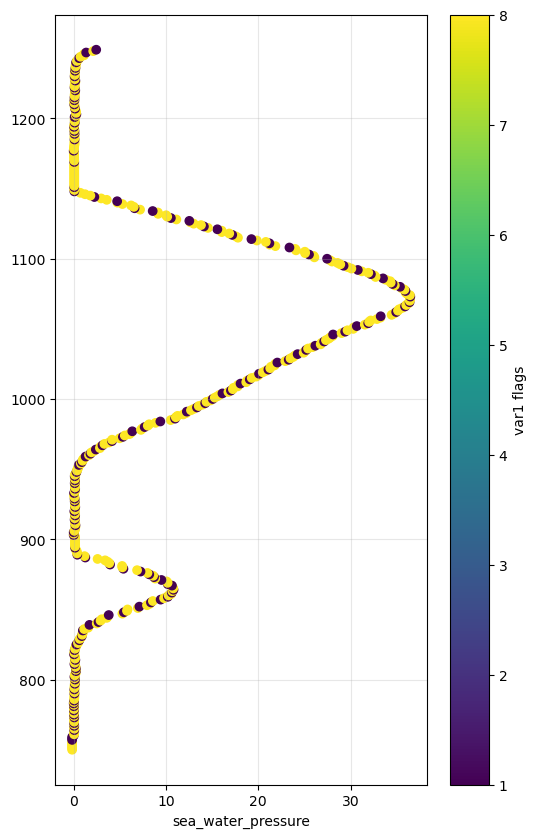

In [5]:
#   Plot the flags as they are
start= 750
end  = 1250

pres = context["data"]["PRES"][start:end]
lat  = context["data"]["LATITUDE"][start:end]
flags= context["data"]["PRES_QC"][start:end]
plot_spike_flags(pres, context["data"]["N_MEASUREMENTS"][start:end], flags)
#   Note that flag 9 will not show up, as the value is NaN

This says that we have a lot of interpolated data, with "good" data periodically spaced inside of it.

Then we run the code...

In [6]:
context_new = Pipe.execute_step(Pipe.steps[-1], _context = context) 

2026-06-17 16:31:38 - INFO - pelagos_py.pipeline - Executing: Apply QC
2026-06-17 16:31:38 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Data found in context.
2026-06-17 16:31:38 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found existing flags columns {'LATITUDE_QC', 'PROFILE_NUMBER_QC', 'CNDC_QC', 'TEMP_QC', 'PRES_QC', 'LONGITUDE_QC'} in data.
2026-06-17 16:31:38 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found QC columns for untested values: {'ALTITUDE_QC', 'DPHASE_DOXY_QC', 'PARAMETER_UNITS_QC', 'OXYCOPVR_QC', 'SENSOR_DATA LOGGERS_397_QC', 'DOWNWELLING_PAR_QC', 'MOLAR_DOXY_QC', 'BPHASE_DOXY_QC', 'DEPLOYMENT_LONGITUDE_QC', 'BBP532_QC', 'LONGITUDE_GPS_QC', 'WATERCURRENTS_U_QC', 'WMO_IDENTIFIER_QC', 'PLATFORM_MODEL_QC', 'DEPLOYMENT_TIME_QC', 'BBP700_QC', 'DEPTH_QC', 'GLIDER_PITCH_QC', 'TIME_QC', 'SENSOR_WATER TEMPERATURE SENSOR_9099_QC', 'GLIDER_DEPTH_QC', 'SENSOR_RADIOMETERS_1611_QC', 'DEPLOYMENT_LATITUDE_QC', 'GLIDER_ROLL_QC', 'PARAMETER_QC', 'PARA

And plot it again...

Flag: Count {np.int64(1): np.int64(141), np.int64(4): np.int64(42), np.int64(8): np.int64(317)}


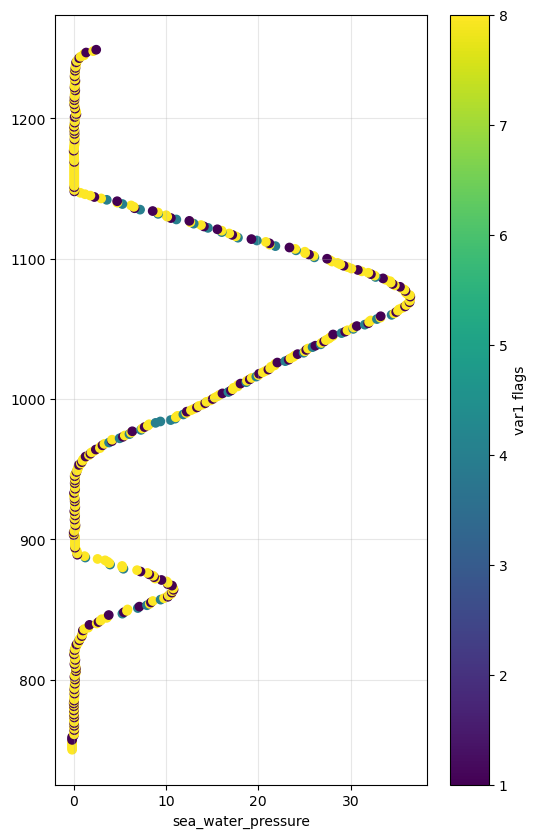

In [7]:
start= 750
end  = 1250

pres = context_new["data"]["PRES"][start:end]
lat  = context_new["data"]["LATITUDE"][start:end]
flags= context_new["data"]["PRES_QC"][start:end]
plot_spike_flags(pres, context_new["data"]["N_MEASUREMENTS"][start:end], flags)

We can rerun it without doing it profile-by-profile

In [8]:
g = Pipe.steps[-1].copy()


In [9]:
g

{'name': 'Apply QC',
 'parameters': {'qc_settings': {'spike qc': {'method': 'rolling median',
    'variables': {'PRES': 2, 'LATITUDE': 1},
    'window_size': 10,
    'by_profile': True,
    'also_flag': {'PRES': ['CNDC', 'TEMP'], 'LATITUDE': ['LONGITUDE']},
    'plot': None}}},
 'diagnostics': False}

In [10]:
g["parameters"]["qc_settings"]["spike qc"]["by_profile"] = False
g

{'name': 'Apply QC',
 'parameters': {'qc_settings': {'spike qc': {'method': 'rolling median',
    'variables': {'PRES': 2, 'LATITUDE': 1},
    'window_size': 10,
    'by_profile': False,
    'also_flag': {'PRES': ['CNDC', 'TEMP'], 'LATITUDE': ['LONGITUDE']},
    'plot': None}}},
 'diagnostics': False}

In [11]:
context_new = Pipe.execute_step(g, _context = context) 

2026-06-17 16:31:41 - INFO - pelagos_py.pipeline - Executing: Apply QC
2026-06-17 16:31:41 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Data found in context.
2026-06-17 16:31:41 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found existing flags columns {'LATITUDE_QC', 'CNDC_QC', 'TEMP_QC', 'PRES_QC', 'LONGITUDE_QC'} in data.
2026-06-17 16:31:41 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found QC columns for untested values: {'ALTITUDE_QC', 'DPHASE_DOXY_QC', 'PARAMETER_UNITS_QC', 'OXYCOPVR_QC', 'SENSOR_DATA LOGGERS_397_QC', 'DOWNWELLING_PAR_QC', 'MOLAR_DOXY_QC', 'BPHASE_DOXY_QC', 'DEPLOYMENT_LONGITUDE_QC', 'BBP532_QC', 'LONGITUDE_GPS_QC', 'WATERCURRENTS_U_QC', 'WMO_IDENTIFIER_QC', 'PLATFORM_MODEL_QC', 'DEPLOYMENT_TIME_QC', 'BBP700_QC', 'DEPTH_QC', 'GLIDER_PITCH_QC', 'TIME_QC', 'SENSOR_WATER TEMPERATURE SENSOR_9099_QC', 'GLIDER_DEPTH_QC', 'SENSOR_RADIOMETERS_1611_QC', 'DEPLOYMENT_LATITUDE_QC', 'GLIDER_ROLL_QC', 'PARAMETER_QC', 'PARAMETER_SENSOR_QC', 'TI

Flag: Count {np.int64(1): np.int64(147), np.int64(8): np.int64(353)}


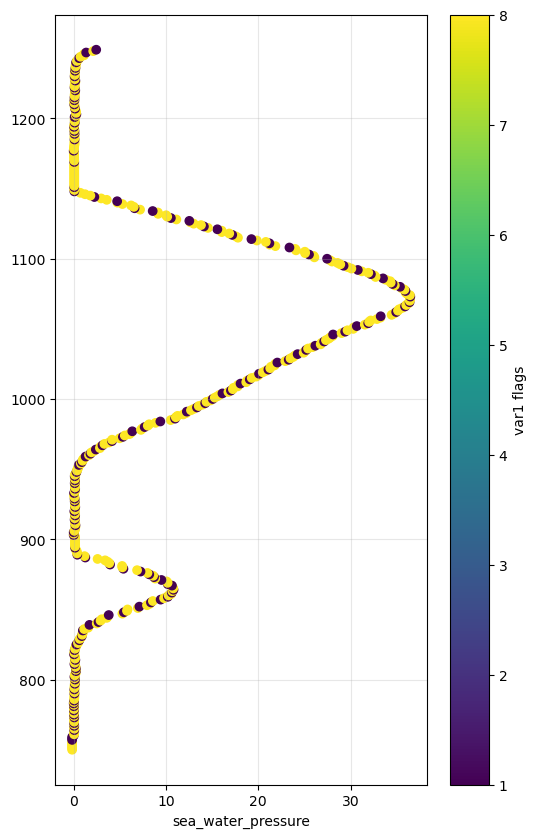

In [12]:
# start= 750
# end  = 1250
pres = context_new["data"]["PRES"][start:end]
lat  = context_new["data"]["LATITUDE"][start:end]
flags= context_new["data"]["PRES_QC"][start:end]
plot_spike_flags(pres, context_new["data"]["N_MEASUREMENTS"][start:end], flags)

Or we can use a different method

2026-06-17 16:31:42 - INFO - pelagos_py.pipeline - Executing: Apply QC
2026-06-17 16:31:42 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Data found in context.
2026-06-17 16:31:42 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found existing flags columns {'LATITUDE_QC', 'CNDC_QC', 'TEMP_QC', 'PRES_QC', 'LONGITUDE_QC'} in data.
2026-06-17 16:31:42 - INFO - pelagos_py.pipeline.step.Apply QC - [Apply QC] Found QC columns for untested values: {'ALTITUDE_QC', 'DPHASE_DOXY_QC', 'PARAMETER_UNITS_QC', 'OXYCOPVR_QC', 'SENSOR_DATA LOGGERS_397_QC', 'DOWNWELLING_PAR_QC', 'MOLAR_DOXY_QC', 'BPHASE_DOXY_QC', 'DEPLOYMENT_LONGITUDE_QC', 'BBP532_QC', 'LONGITUDE_GPS_QC', 'WATERCURRENTS_U_QC', 'WMO_IDENTIFIER_QC', 'PLATFORM_MODEL_QC', 'DEPLOYMENT_TIME_QC', 'BBP700_QC', 'DEPTH_QC', 'GLIDER_PITCH_QC', 'TIME_QC', 'SENSOR_WATER TEMPERATURE SENSOR_9099_QC', 'GLIDER_DEPTH_QC', 'SENSOR_RADIOMETERS_1611_QC', 'DEPLOYMENT_LATITUDE_QC', 'GLIDER_ROLL_QC', 'PARAMETER_QC', 'PARAMETER_SENSOR_QC', 'TI

Flag: Count {np.int64(1): np.int64(147), np.int64(8): np.int64(353)}


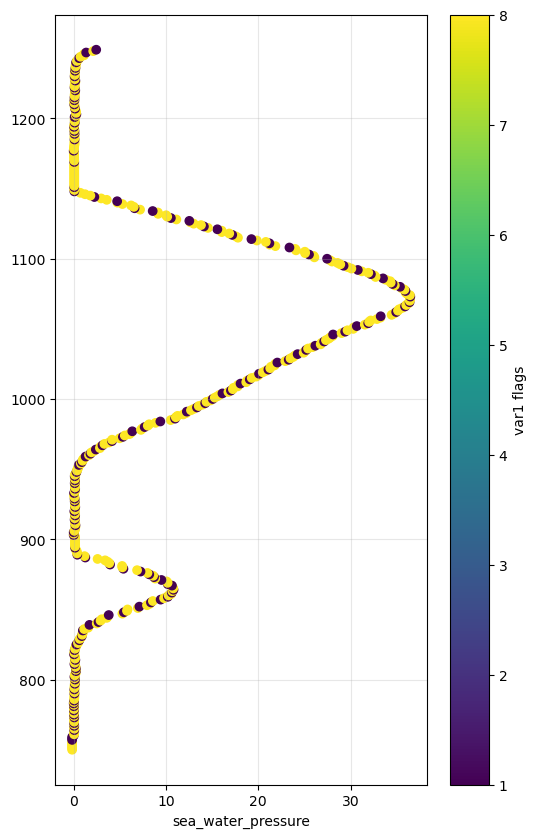

In [13]:
g = Pipe.steps[-1].copy()
g["parameters"]["qc_settings"]["spike qc"]["by_profile"] = False
g["parameters"]["qc_settings"]["spike qc"]["method"] = "qartod"
context_qartod = Pipe.execute_step(g, _context = context)
pres = context_qartod["data"]["PRES"][start:end]
lat  = context_qartod["data"]["LATITUDE"][start:end]
flags= context_qartod["data"]["PRES_QC"][start:end]
plot_spike_flags(pres, context_qartod["data"]["N_MEASUREMENTS"][start:end], flags)